In [1]:
from HARey.harey_main import HAReyMain
import numpy as np
import matplotlib.pyplot as plt

In [2]:
harey = HAReyMain()


Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey/HARey/cardbacks/tarot_round.png


In [3]:
harey.colors['shadow']='red'

hip
1         False
2         False
3         False
4         False
5         False
          ...  
118318    False
118319    False
118320    False
118321    False
118322    False
Length: 116937, dtype: bool


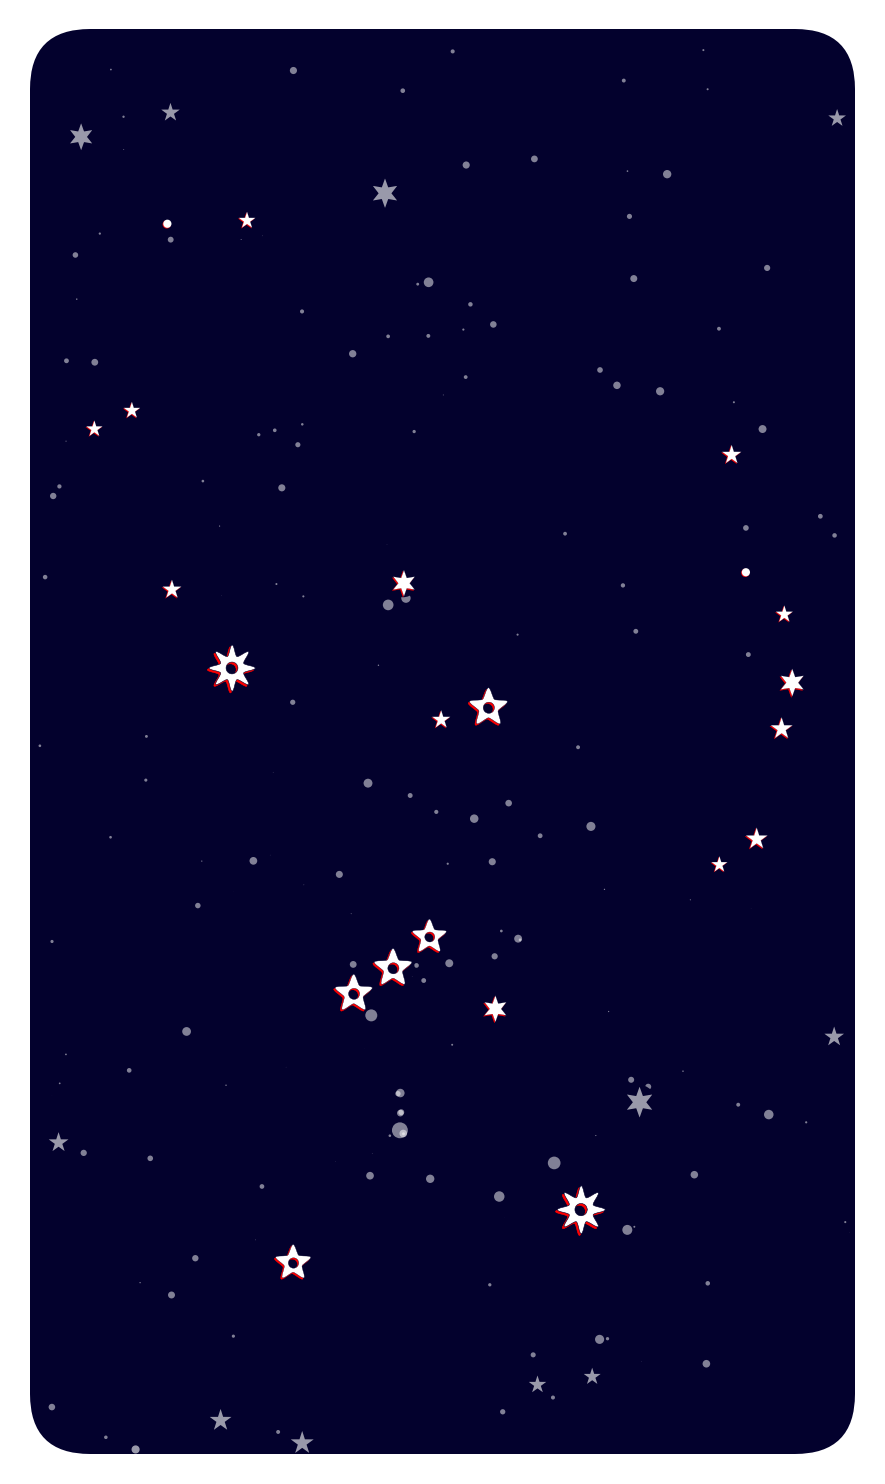

In [4]:
harey.plot_card('Ori')

hip
1         False
2         False
3         False
4         False
5         False
          ...  
118318    False
118319    False
118320    False
118321    False
118322    False
Length: 116937, dtype: bool


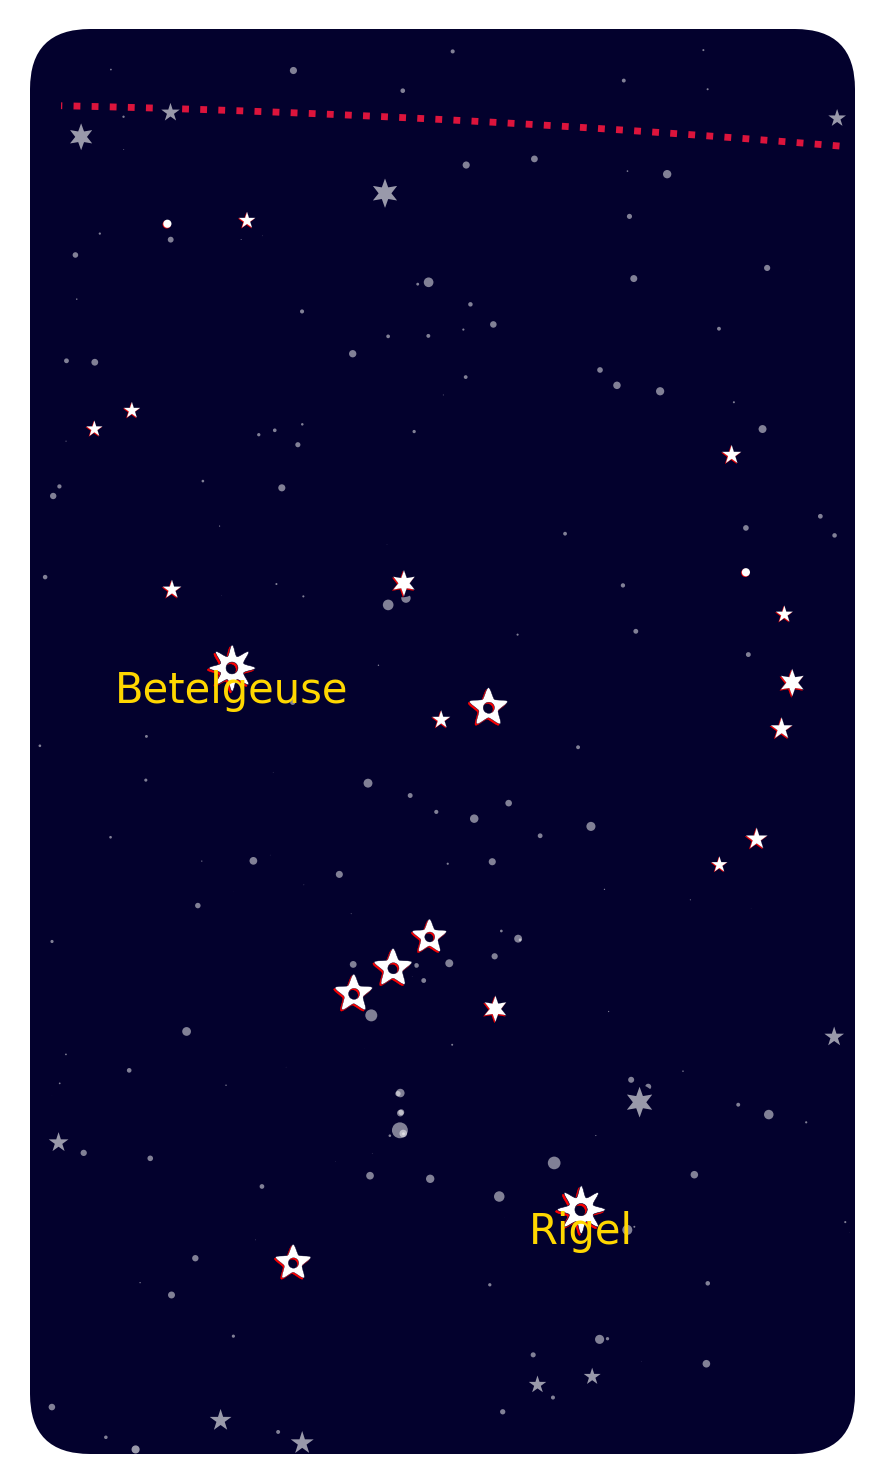

In [5]:
harey.set_flags({'CON_LINES':True, 'STAR_NAMES':True})
harey.plot_card('Ori')

hip
1         True
2         True
3         True
4         True
5         True
          ... 
118318    True
118319    True
118320    True
118321    True
118322    True
Name: ra, Length: 116937, dtype: bool
hip
1         False
2         False
3         False
4         False
5         False
          ...  
118318    False
118319    False
118320    False
118321    False
118322    False
Name: ra, Length: 116937, dtype: bool


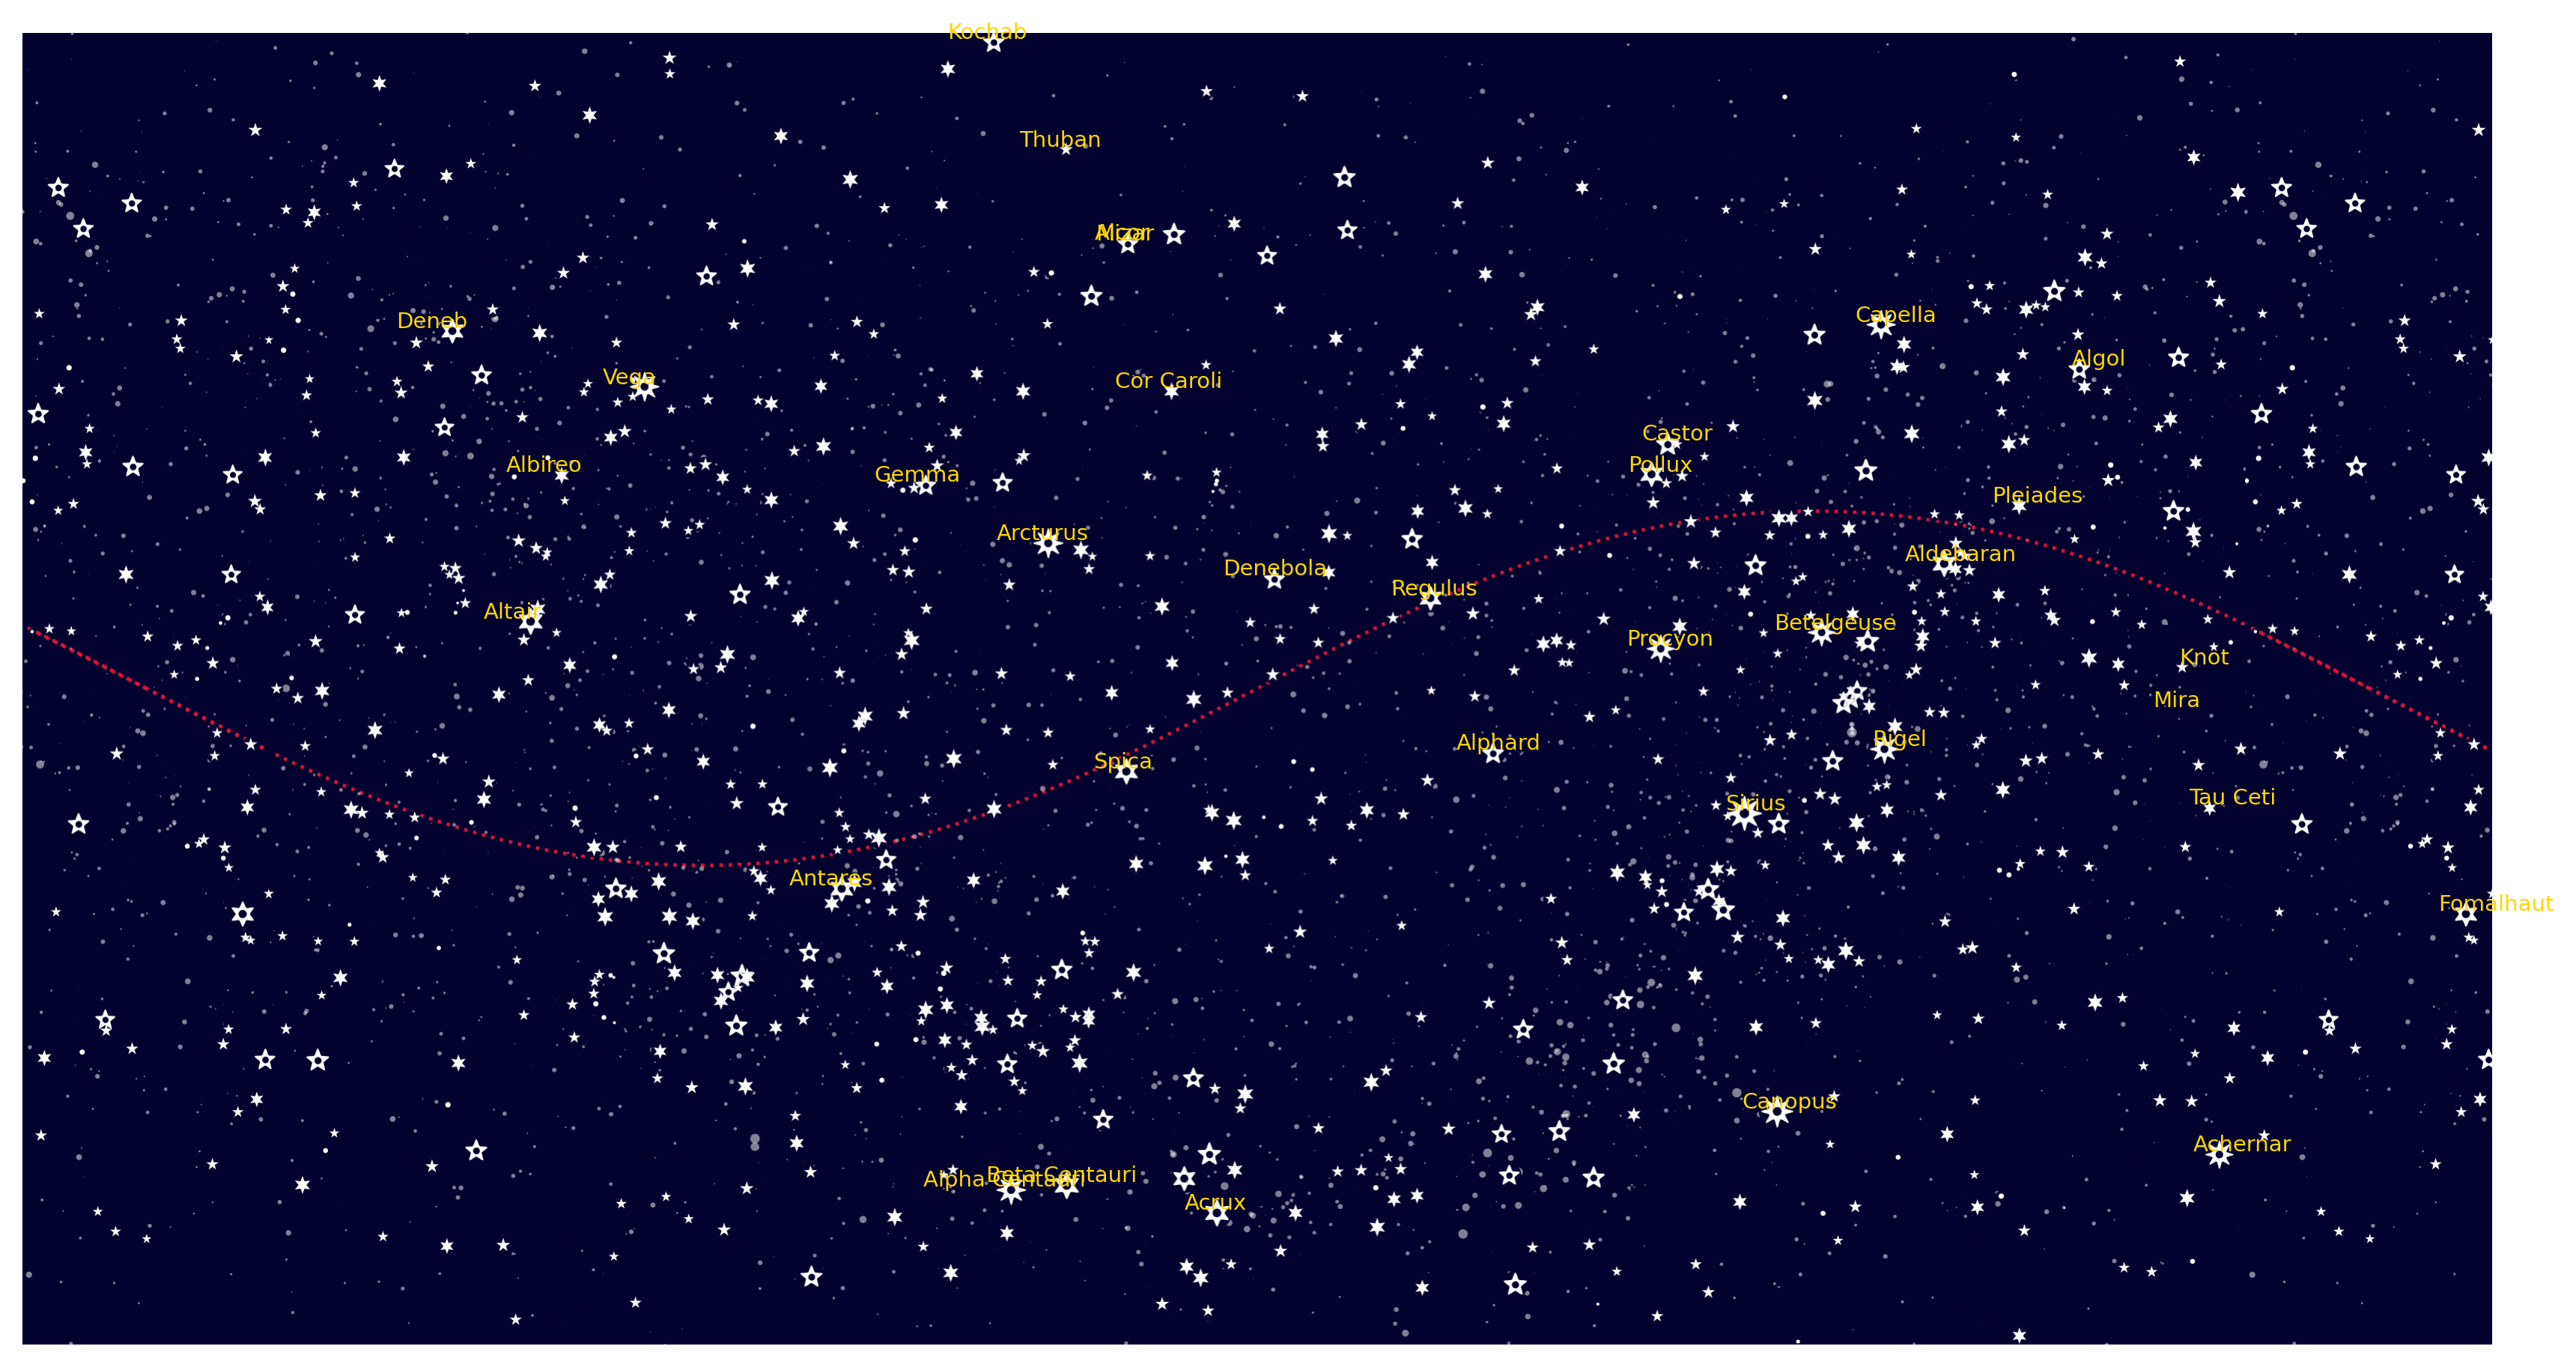

In [6]:
harey.equatorial_map()

In [7]:
a = np.array([0,1,0,0,1], dtype=bool)
b = np.array([0,1,1,0,1], dtype=bool)

x = np.arange(5)

In [8]:
for a,b in zip(x[:-1], x[1:]):
    print(a,b)
    if mask[a] or mask[b]:
        print('point inside')

0 1


NameError: name 'mask' is not defined

In [ ]:
import pandas as pd

In [ ]:
a = np.random.uniform((0,0),(3,3), (100,2))
a = pd.DataFrame(a, columns=['x','y'])

print(a)
mask = lambda x, y : x > 1 & (x < 2) & (y > 1) & y < 2

print(mask(a['x'], a['y']))

plt.plot(a['x'], a['y'], 'o')
plt.plot(a['x'][mask(a['x'], a['y'])], a['y'][mask(a['x'], a['y'])], 'ro')



           x         y
0   2.676168  0.727490
1   2.442638  0.783226
2   1.601170  0.979477
3   1.417685  2.869852
4   0.951986  2.538664
..       ...       ...
95  2.942853  1.510623
96  2.700761  1.537344
97  0.144578  1.059127
98  0.901087  2.116406
99  0.757985  2.622405

[100 rows x 2 columns]


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
from matplotlib.patches import FancyBboxPatch

In [ ]:
def plot_card(self, id, BEST_AR = False, save_name = None, star_size = 200, font_size = 10):
    """
    Plot the constellation card inside the card template.    
	Font and star sizes are relative to the card area and FOV, so that the plot looks similar with different FOVs and templates.
    
    Arguments:
        - id (str): Constellation ID (e.g. 'Ori' for Orion).
        - BEST_AR (bool): If True, rotate the constellation to better fit inside the card. Otherwise, plot with North side up
        - save_name (str): Name of the file to save the plot. If None, saves as 'id_lines.png' or 'id_bare.png'
        - star_size (float): Relative size of the stars in the plot.
        - font_size (float): Size of the small labels in the plot (no big labels are plotted).
    """ 

    self.is_constellation(id)

    # If the save_name is not None or SIS_SCRIPT is enabled, save automatically the plot
    if not save_name == None or self.flags['SIS_SCRIPT']:
        self.flags['SAVE'] = True

    # Default file name
    if self.flags['SAVE'] and save_name==None:
        save_name = f'{id}_{'lines' if self.flags['CON_LINES'] else 'bare'}.png'

    # Project the sky around the constellation
    (stars_x, stars_y), (x_span, y_span), (ecliptic_x, ecliptic_y), north_angle = project_region(self, id, BEST_AR=BEST_AR)     

    # Get the plot dimensions
    if self.box_style == 'circle, pad=0.0':
        # If the plot is in a circle, compute the radius on the corner of the plot
        map_radius = np.sqrt(x_span**2 + y_span**2)
        x_span = (1 + 2 * (self.pad + self.bleed)/self.height)*map_radius
        y_span = x_span
    else:
        #Adjust the figure enlarging either the x or y direction to get the wanted aspect ratio, while adding a little padding
        #Also, if self.bleed is enabled, add extra bleed to completely cover the cardback and avoid misalignement when cutting the cards
        if (x_span/y_span < self.AR_plot):
            # If the constellation is thinner than the plot area, pad y and enlarge the x span to fit the whole card
            y_span = (1 + 2 * (self.pad + self.bleed) /self.height) * y_span
            x_span = y_span*self.AR_card
        else:
            # If the constellation is thicker, pad x and enlarge the y span to fit the whole card
            x_span = (1 + 2 * (self.pad + self.bleed) /self.width) * x_span
            y_span = x_span/self.AR_card

    # Scale the star sizes and the text labels based on the card area and the region of sky plotted
    marker_scale = self.width*self.height/(2.75*4.75)      # Scale w.r.t the standard card (tarot)
    area_scale = np.sqrt(0.01/(x_span*y_span))     # Scale w.r.t the area of sky plotted

    marker_size = star_size*marker_scale*area_scale
    font_size = round(np.sqrt(marker_scale)*font_size)

    #Get the north star marker
    north_marker = self.markers['north_star']

    # Create the figure
    fig,ax = plt.subplots(figsize = (self.width + 2*self.bleed, self.height + 2*self.bleed), dpi=self.dpi) #figure with correct aspect ratio
    fig.subplots_adjust(0,0,1,1)

    # center around zero
    height = self.height/2 + self.bleed
    width = self.width/2 + self.bleed

    # Set ax limits
    ax.set_xlim(-width,width)
    ax.set_ylim(-height,height)
    ax.set_aspect('equal')
    ax.set_axis_off()

    # Scale the coordinates
    scale = height/y_span        
    
    # If the bleed is not zero, set the box to a simple rectangular box with no rounded corners
    box_style = 'square, pad=0.0' if self.bleed > 0.0 else self.box_style

    # Apply the card template patch
    box = FancyBboxPatch(xy=(-width,-height), width=2*width, height=2*height, boxstyle=box_style,
                        fill=True, facecolor=self.colors['sky'], edgecolor=None, linewidth=0)    
    ax.add_patch(box)

    # Rescale the ecliptic and star positions
    stars_x, stars_y = stars_x*scale, stars_y*scale
    ecliptic_x, ecliptic_y = scale*ecliptic_x, scale*ecliptic_y

    # Condition for plotting lines to avoid crossing the plot.
    if self.box_style == 'circle, pad=0.0':
        # If the map is clipped to a circle, stars in the clipped regions could still be connected
        not_outside = lambda x,y: x**2 + y**2 > height**2
    else: 
        # In the other cases, check if at least a point is inside the borders
        not_outside = lambda x,y: (x>-width) & (x<width) & (y>-height) & (y<height)

    # Plot the map using the shared plot_map function
    plot_map(self, ax=ax, box=box, stars_xy=(stars_x,stars_y), ecliptic_xy=(ecliptic_x, ecliptic_y),\
             marker_size=marker_size, not_outside=not_outside, con_highlight=[id], font_size=font_size)

    #Plot the North indicator as last thing
    if BEST_AR: 
        #The angle is between -90 and 90 and plotted near the edge of the card
        space = 0.7*self.pad + self.bleed

        plot_width, plot_height = width-space, height-space
        
        # If the plot is round, the plot is much easier
        if self.box_style == 'circle, pad=0.0':
            (x,y) = (plot_height*np.sin(north_angle), plot_height*np.cos(north_angle))

        else:
            # Angle of the intersection of the horizontal and vertical edge
            card_angle = np.arctan(plot_width/plot_height)
            # The indicator is plotted near the closest edge
            
            # If the angle is less than the minus card angle, plot it on the left side
            if north_angle <= -card_angle:
                (x,y) = (-plot_width, -(plot_width)/np.tan(north_angle))
            # It the angle is more than the card angle, plot it on the right side
            elif north_angle >= card_angle:  
                (x,y) = (plot_width, (plot_width)/np.tan(north_angle))
            # Otherwise, plot it on the upper side
            else:
                (x,y) = ((plot_height)*np.tan(north_angle), plot_height)    

        t = Affine2D().rotate_deg(180 + np.rad2deg(-north_angle))
        ax.plot(x,y, marker=MarkerStyle(north_marker, transform=t), markersize=font_size, color=self.colors['cardinal_markers'], markeredgewidth=0)

    # Clip everything to the box plot
    for col in ax.collections:
        col.set_clip_path(box)

    if self.flags['SIS_SCRIPT']:  # Save the iamge bfore adding labels
        plt.savefig(save_name, dpi = self.dpi, transparent=True, bbox_inches='tight', pad_inches=0)
        
    # Function to plot a label at the mean x and y positions
    def plot_label(ax, label, indexes, color, fontsize, ha='center', va = 'center'):
        """Take the mean x and y and plot a label there."""
        label_x = np.mean(stars_x[indexes])
        label_y = np.mean(stars_y[indexes])
        ax.text(label_x, label_y, label, color=color, fontsize=fontsize, font=self.fonts['labels'],  ha = ha, va = va) 


    if self.flags['STAR_NAMES']:
        # Plot named stars
        for star in self.cons[id]['stars']:
            if str(star) in self.names:
                plot_label(ax, self.names[str(star)], indexes = star, color=self.colors['star_labels'], fontsize=font_size, ha='center',va='top')
        
    if self.flags['CON_PARTS']: 
        # Plot constellation parts
        for key in [key for key in self.cons.keys() if key.startswith(f'.{id}')]:
            plot_label(ax, self.names[key], indexes = self.cons[key]['stars'], color=self.colors['constellation_parts'], fontsize=font_size, ha='center',va='center')


    if self.flags['SIS_SCRIPT']:  
        # Create a script to plot interactive labels in Inkscape, to manually adjust their positions                
        # To make the position consistent with different settings of Inkscape, 
        # the coordinates are fractions of the card self.width and self.height, starting from top left

        def write_sis(file, label, indexes, color, fontsize):
            # The newline character does not work in inkscape. The label is divided in two
            labels = label.split('\n')
        
            for label in labels:
                label_x = np.mean(stars_x[indexes])
                label_y = np.mean(stars_y[indexes])
                # Relative position of the labels w.r.t the image, from top left
                label_x, label_y = 0.5 + label_x/(2*self.width), 0.5 - label_y/(2*self.height)
                s = f"text('{label}', ({label_x:.2f}*canvas.self.width, {label_y:.2f}*canvas.self.height), font_size='{fontsize}pt', " \
                    f"text_anchor='middle', font_family='{self.fonts['labels'].get_name()}', fill='{to_hex(color)}')\n"
                file.write(s)         

        dir = 'inkscape_scripts'    # Folder of the scripts
        if not os.path.exists(dir):
            os.mkdir(dir)
        with open(f'{dir}/labels_{id}.py', 'w') as f:

            f.write('# Named stars labels\n')
            # Plot star labels
            if self.flags['STAR_NAMES']:
                for star in self.cons[id]['stars']:
                    if str(star) in self.names:
                        write_sis(f, self.names[str(star)], star, color=self.colors['star_labels'], fontsize = 10)
                
            f.write('\n# Constellation parts labels\n')
            # Plot constellation parts
            if self.flags['CON_PARTS']:
                for key in [key for key in self.cons.keys() if key.startswith(f'.{id}')]:
                    write_sis(f, self.names[key], self.cons[key]['stars'], fontsize=font_size, color=self.colors['constellation_parts'])

            if self.flags['CON_LINES']:
                f.write('\n# Ecliptic label\n')
                # Add a label close to the ecliptic if it is inside the constellation
                mask = ((ecliptic_x > -self.width) & (ecliptic_x < self.width) & (ecliptic_y > -self.height) & (ecliptic_y < self.height)).tolist()
                
                if np.any(mask):
                    label_x = np.mean(ecliptic_x[mask])/(2*self.width) + 0.5
                    label_y = - np.mean(ecliptic_y[mask])/(2*self.height) + 0.5
                    s = f"text('{self.names['ecl']}', ({label_x:.2f}*canvas.self.width, {label_y:.2f}*canvas.self.height), font_size='{font_size}pt'," \
                        f"text_anchor='middle', font_family='{self.fonts['labels'].get_name()}', fill='{to_hex(self.colors['ecliptic_label'])}')\n"
                    f.write(s)

    if self.flags['SAVE'] and not self.flags['SIS_SCRIPT']:            
        plt.savefig(save_name, dpi = self.dpi, transparent=True, bbox_inches='tight', pad_inches=0)

    if self.flags['SHOW']:
        plt.show()
    else:
        plt.close()

In [ ]:
def plot_map(self, ax, box, stars_xy, ecliptic_xy, marker_size, not_outside, con_highlight=[], asterism_highlight=[], helper_highlight=[], is_inverted=False, font_size=15):

    stars_x, stars_y = stars_xy
    ecliptic_x, ecliptic_y = ecliptic_xy

    line_w = marker_size * 0.0075
    star_sizes = marker_size*mag2size(self.stars['magnitude'], lim_mag=self.limiting_magnitude, lim_mag_size=self.limit_size)

    mask_inside = not_outside(stars_x, stars_y)
    print(mask_inside)

    # Plot constellation lines
    if self.flags['CON_LINES']:

        lines = []
        for constellation_id in self.con_ids:
            # if there are constellation to highlight, make the other less evident
            alpha = 0.5 if len(con_highlight)>0 and not constellation_id in con_highlight else 1

            for line in [line for line in self.cons[constellation_id]['lines']]:
                # Divide the line in individual segments
                for a,b in zip(line[1:], line[:-1]):
                    if mask_inside[a] or mask_inside[b]:

                        lines.append((stars_x[a], stars_y[a], stars_x[b], stars_y[b]))
                        
                        '''plot_line, = ax.plot(stars_x[segment], stars_y[segment], color=self.colors['shadow'],\
                                                linewidth=1.5*line_w, alpha=alpha)
                        plot_line.set_clip_path(box)
                        plot_line, = ax.plot(stars_x[segment], stars_y[segment], color=self.colors['constellations'],\
                                                linewidth=line_w, alpha=alpha)
                        plot_line.set_clip_path(box)'''

        lc = LineCollection(lines, colors='green', linewidths=line_w)

    #Plot asterisms
    if self.flags['ASTERISMS'] or len(asterism_highlight)>0:
        
        asterism_ids = self.asterisms.keys() if len(asterism_highlight)==0 else asterism_highlight

        for line in [line for id in asterism_ids for line in self.asterisms[id]['lines']]:
            # Divide the line in individual segments
                for segment in [[a,b] for a, b in zip(line[1:], line[:-1])]:
                    if not_outside(stars_x[segment], stars_y[segment]):
                        plot_line, = ax.plot(stars_x[segment], stars_y[segment], color=self.colors['asterisms'],\
                                        linestyle='solid', linewidth=line_w)
                        plot_line.set_clip_path(box)

    #Plot helpers
    if self.flags['HELPERS'] or len(helper_highlight)>0:

        helper_ids = self.helpers.keys() if len(helper_highlight)==0 else helper_highlight

        for line in [line for id in helper_ids for line in self.helpers[id]['lines']]: 
            # Divide the line in individual segments
            for segment in [[a,b] for a, b in zip(line[1:], line[:-1])]:
                if not_outside(stars_x[segment], stars_y[segment]):
                    plot_line, = ax.plot(stars_x[segment], stars_y[segment], color=self.colors['helpers'], \
                                linestyle='dashed', linewidth=0.7*line_w)
                    plot_line.set_clip_path(box)

    #Draw ecliptic 
    if self.flags['CON_LINES'] and self.flags['ECLIPTIC']:
        for i in range(0,361,10):
            if not_outside(ecliptic_x[i:i+11], ecliptic_y[i:i+11]):
                ecliptic, = ax.plot(ecliptic_x[i:i+11], ecliptic_y[i:i+11], color=self.colors['ecliptic'], linestyle='dotted', \
                           linewidth=1.5* line_w)
                ecliptic.set_clip_path(box) 


    
    # Stars that are not in a constellation shape are represented with a dot
    bkg_stars = np.logical_and(self.stars.constellation == 'none', self.stars.magnitude <= self.limiting_magnitude)        
    color = self.stars[bkg_stars]['color'] if self.flags['STAR_COLORS'] else self.colors['star']

    # Plot bkg stars
    ax.scatter(stars_x[bkg_stars], stars_y[bkg_stars],s=star_sizes[bkg_stars], color=color, marker=".", linewidths=0, zorder=2, alpha=0.5)  # type: ignore

    # If HAREY, use the custom star markers, else use simple dots
    star_markers = self.harey_markers if self.flags['HAREY_MARKERS'] else ['.']*len(self.harey_markers)

    # Plot a blank circle around the main stars to make them more evident
    main_stars = self.stars.constellation != 'none'
    ax.scatter(stars_x[main_stars], stars_y[main_stars], marker='o', s=1.15*star_sizes[main_stars], color=self.colors['sky'], linewidths=0, zorder=2)
                   
    offset = 5e-4  
    for i, m in enumerate(star_markers):
         # Get the stars that are part of a constellation shape
        mask = np.logical_and(self.stars.mag_class == i, main_stars)

        if len(con_highlight) > 0:
            # If there are constellations to highlight, plot the stars in the highlighted constellation with a different alpha
            
            highlight_mask = self.stars.constellation.isin(con_highlight)
            mask_highlight = np.logical_and(mask, highlight_mask) 

            # Plot the highlighted stars
            off = offset*np.sqrt(star_sizes[mask_highlight])
            ax.scatter(stars_x[mask_highlight]-off, stars_y[mask_highlight]-off, \
                       marker=m, s=star_sizes[mask_highlight],\
                        color=self.colors['shadow'], linewidths=0.001*star_sizes[mask_highlight], edgecolor=self.colors['shadow'], zorder=2)

            color = self.stars[mask_highlight]['color'] if self.flags['STAR_COLORS'] else self.colors['star']
            ax.scatter(stars_x[mask_highlight], stars_y[mask_highlight], marker=m, s=star_sizes[mask_highlight],\
                        color=color, linewidths=0.001*star_sizes[mask_highlight], edgecolor=self.colors['sky'], zorder=2) 
            
            mask_others = np.logical_and(mask, ~highlight_mask)

            # Plot the other stars
            color = self.stars[mask_others]['color'] if self.flags['STAR_COLORS'] else self.colors['star']
            ax.scatter(stars_x[mask_others], stars_y[mask_others], marker=m,  \
                       s=star_sizes[mask_others], color=color, linewidths=0, edgecolor=self.colors['sky'], zorder=2, alpha=0.6) 



        else:
            color = self.stars[mask]['color'] if self.flags['STAR_COLORS'] else self.colors['star']
            ax.scatter(stars_x[mask], stars_y[mask], marker=m, s=star_sizes[mask], \
                       color=color, linewidths=0.001*star_sizes[mask], edgecolor=self.colors['sky'], zorder=2)
            
    # Draw the zodiac
    if self.flags['ZODIAC']:
        c = -1 if is_inverted else 1
        for i, symbol in enumerate(self.zodiac_symbols):
                # Place triangular markers to indicate the start and end of zodiacal signs 
                if not_outside(ecliptic_x[30*i], ecliptic_y[30*i]):
                    angle = np.rad2deg( np.atan2( ecliptic_y[30*i+1]-ecliptic_y[30*i],  c*(ecliptic_x[30*i+1]-ecliptic_x[30*i])))
                    t = Affine2D().rotate_deg(angle)
                    marker = ax.scatter((ecliptic_x[30*i]), (ecliptic_y[30*i]), marker=MarkerStyle('>', transform=t), color = self.colors['ecliptic'], s =0.2*marker_size, linewidths=0)
                    marker.set_clip_path(box)

                # Place the zodiacal sign
                if not_outside(ecliptic_x[30*i+15], ecliptic_y[30*i+15]):

                    ax.scatter(ecliptic_x[30*i+15], ecliptic_y[30*i+15], marker='o', s=3*font_size**2, color=self.colors['sky'], linewidths=0, zorder=2)
                    ax.annotate( symbol, xy = (ecliptic_x[30*i+15],(ecliptic_y[30*i+15])), color=self.colors['ecliptic'], ha='center', va='center', fontsize= 1.5*font_size, zorder=2)

    

hip
1         False
2         False
3         False
4         False
5         False
          ...  
118318    False
118319    False
118320    False
118321    False
118322    False
Length: 116937, dtype: bool


NameError: name 'LineCollection' is not defined

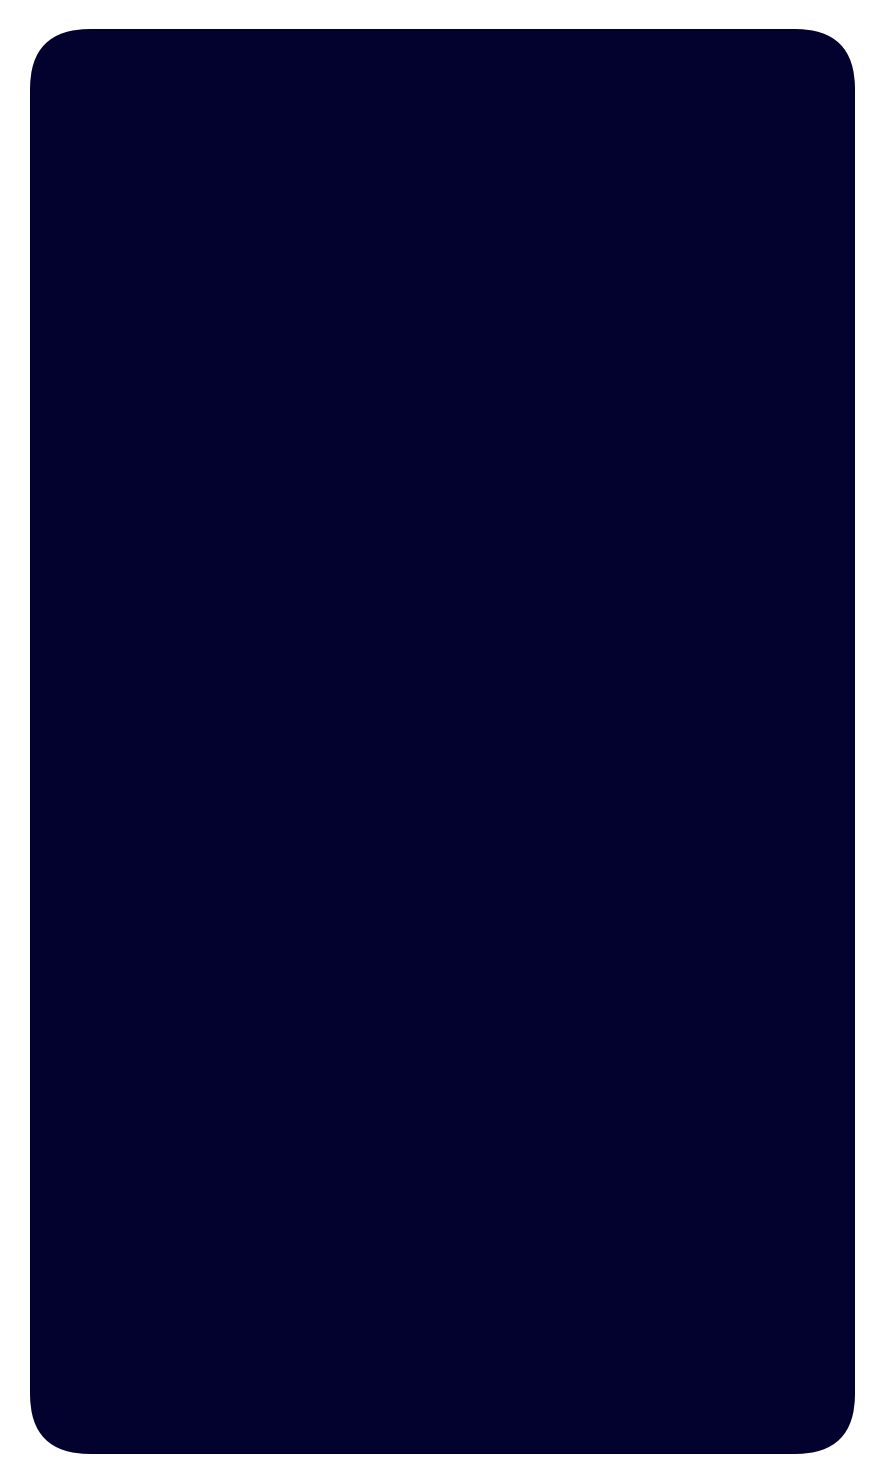

In [ ]:
from HARey import card_plot
from HARey.astro_functions import mag2size
from HARey.projections import project_region

harey.set_flags({'CON_LINES':True, 'STAR_NAMES':True})
plot_card(harey, 'Ori')